In [24]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE

In [26]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")

In [27]:
ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts)

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.04253508559518549, `time`: 0.0449s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x29d29d3b110>])

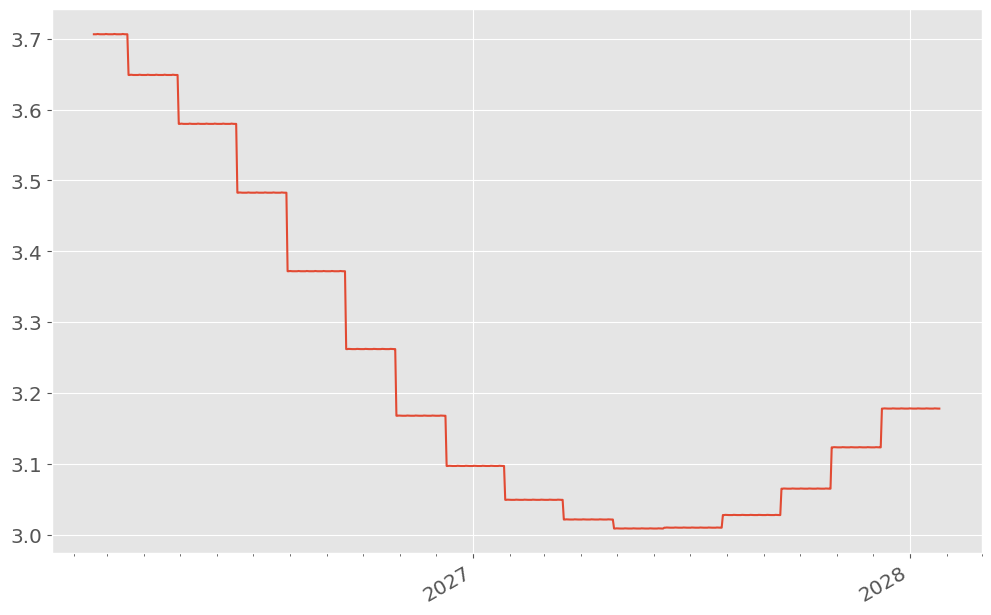

In [28]:
curve.plot("1d")

In [30]:
pricers = stirf_mdp.get_data({"symbols": ["SERCM1"], "timestamp": ts})

In [35]:
pricers["SERCM1"][0].build_pricable()